In [ ]:

# Устанавливаем чистый torch-geometric (он сам подтянет всё необходимое)
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.9 MB/s eta 0:00:00


In [ ]:
import torch
import networkx as nx
import numpy as np
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.utils import to_networkx

# 1. Загрузка исходного датасета
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]

print("="*50)
print(" ИССЛЕДОВАНИЕ ДАННЫХ (EDA) ДЛЯ ГРАФА CORA")
print("="*50)

# 2. Базовые характеристики графа
num_nodes = data.num_nodes
num_edges = data.num_edges
num_features = data.num_features
num_classes = dataset.num_classes

print(f" Количество узлов (статей): {num_nodes}")
print(f" Количество ребер (связей цитирования): {num_edges}")
print(f" Размерность вектора признаков (слов в словаре): {num_features}")
print(f" Количество классов (тем статей): {num_classes}")

# 3. Анализ структуры и связности
# Плотность графа (Graph Density): отношение существующих ребер к максимально возможным
# Формула для ненаправленного графа: 2 * E / (V * (V - 1))
density = (2 * num_edges) / (num_nodes * (num_nodes - 1))
print(f" Плотность графа: {density:.5f} (граф сильно разреженный)")

# Проверка на наличие изолированных узлов и петель
print(f" Есть ли изолированные узлы: {data.has_isolated_nodes()}")
print(f" Есть ли петли (self-loops): {data.has_self_loops()}")
print(f" Направленный ли граф: {data.is_directed()}")

# 4. Анализ степеней узлов (Degree Analysis)
# Считаем, сколько связей имеет каждый узел
row, col = data.edge_index
degrees = torch.bincount(row).float()

max_degree = int(degrees.max().item())
min_degree = int(degrees.min().item())
mean_degree = float(degrees.mean().item())

print(f"Максимальная степень узла: {max_degree}")
print(f" Минимальная степень узла: {min_degree}")
print(f" Средняя степень узла: {mean_degree:.2f}")

# 5. Анализ распределения классов (категорий статей)
labels = data.y.numpy()
unique_classes, counts = np.unique(labels, return_counts=True)

print("\nРаспределение статей по классам:")
for cls, count in zip(unique_classes, counts):
    percentage = (count / num_nodes) * 100
    print(f"   Класс {cls}: {count} статей ({percentage:.2f}%)")

# 6. Продвинутые метрики топологии (через NetworkX)
# Переводим в формат NetworkX для расчета сложных метрик
# Конвертируем как ненаправленный граф, так как RandomLinkSplit делает граф ненаправленным
G = to_networkx(data, to_undirected=True)

print("\n Топологические метрики графа:")
# Количество компонент связности
num_components = nx.number_connected_components(G)
print(f"   Количество компонент связности: {num_components}")

# Размер наибольшей компоненты связности
largest_cc = max(nx.connected_components(G), key=len)
print(f"   Доля узлов в гигантской компоненте: {len(largest_cc)/num_nodes*100:.2f}%")

# Средний коэффициент кластеризации (насколько узлы склонны образовывать группы)
avg_clustering = nx.average_clustering(G)
print(f"   Средний коэффициент кластеризации: {avg_clustering:.4f}")

print("="*50)
print("EDA успешно завершено. Данные готовы к передаче в GAE.")
print("="*50)


 ИССЛЕДОВАНИЕ ДАННЫХ (EDA) ДЛЯ ГРАФА CORA
 Количество узлов (статей): 2708
 Количество ребер (связей цитирования): 10556
 Размерность вектора признаков (слов в словаре): 1433
 Количество классов (тем статей): 7
 Плотность графа: 0.00288 (граф сильно разреженный)
 Есть ли изолированные узлы: False
 Есть ли петли (self-loops): False
 Направленный ли граф: False
Максимальная степень узла: 168
 Минимальная степень узла: 1
 Средняя степень узла: 3.90

Распределение статей по классам:
   Класс 0: 351 статей (12.96%)
   Класс 1: 217 статей (8.01%)
   Класс 2: 418 статей (15.44%)
   Класс 3: 818 статей (30.21%)
   Класс 4: 426 статей (15.73%)
   Класс 5: 298 статей (11.00%)
   Класс 6: 180 статей (6.65%)

 Топологические метрики графа:
   Количество компонент связности: 78
   Доля узлов в гигантской компоненте: 91.77%
   Средний коэффициент кластеризации: 0.2407
EDA успешно завершено. Данные готовы к передаче в GAE.


1. Структура и плотность графа (Топология)Экстремальная разреженность: Плотность графа составляет всего 0.00288 (менее 0.3% от максимально возможного числа связей). Это классический признак реальных графов цитирования. Для модели графового автоэнкодера (GAE) это означает, что задача предсказания связей (Link Prediction) будет проходить в условиях жесткого дефицита позитивных примеров.Связность графа: В графе выделено 78 изолированных компонент, однако 91.77% всех узлов сосредоточены в одной гигантской компоненте (Giant Connected Component). Это отличная новость для сверточных слоев GCN: подавляющее большинство узлов могут эффективно обмениваться сообщениями (message passing) друг с другом через несколько шагов.Локальная сплоченность: Средний коэффициент кластеризации равен 0.2407. Для настолько разреженного графа это высокий показатель. Он говорит о том, что статьи склонны формировать плотные локальные сообщества (клики, где «друзья моих друзей — мои друзья»). GAE будет легко восстанавливать связи внутри таких кластеров.

2. Анализ степеней узлов (Метрики связей)Структура безмасштабной сети: Наблюдается колоссальный разрыв между средней степенью узла (3.90) и максимальной (168). На одну статью в среднем приходится около 4 цитирований, но в графе есть выраженные «хабы» — супер-популярные статьи со 168 связями.Отсутствие аномалий: Минимальная степень узла равна 1, а изолированные узлы отсутствуют (False). Это гарантирует, что у каждого узла есть хотя бы один сосед, и у GCN-энкодера не возникнет проблем с «пустым» агрегированием признаков. Петли (self-loops) отсутствуют, поэтому граф не имеет избыточных связей «на самого себя».

3. Специфика признаков и баланс классовВысокая размерность признаков: Каждый узел описывается вектором из 1433 признаков (бинарные индикаторы наличия слов). Так как признаков много, а среднее число соседей мало (3.90), модель должна сильно опираться на текстовое содержимое статьи, а не только на структуру связей. Наличие T.NormalizeFeatures() в коде критически важно, чтобы нормализовать эти разреженные векторы.Дисбаланс классов: В данных присутствует явный дисбаланс. Самый крупный класс (Класс 3) занимает 30.21% датасета (818 статей), в то время как самый малочисленный (Класс 6) — всего 6.65% (180 статей). Хотя GAE обучается без учителя на структуре связей (восстановление ребер), этот дисбаланс может влиять на то, что внутри Класса 3 плотность ребер будет выше, и модель может смещать свои предсказания в сторону более популярных тематик.

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Загрузка данных (Граф цитирования Cora)
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]

# Современное разделение ребер (выделяем валидацию и тест)
transform = T.RandomLinkSplit(
    num_val=0.05,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True
)
train_data, val_data, test_data = transform(data)

# 2. Архитектура Энкодера (GCN)
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        return self.conv2(x, edge_index)

# 3. Архитектура Графового Автоэнкодера (GAE)
class GraphAutoencoder(nn.Module):
    def __init__(self, encoder):
        super(GraphAutoencoder, self).__init__()
        self.encoder = encoder

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def decode(self, z, edge_label_index):
        # Достаем индексы начальных и конечных узлов ребер
        nodes_src = edge_label_index[0]
        nodes_dst = edge_label_index[1]
        # Считаем скалярное произведение для пар узлов
        value = (z[nodes_src] * z[nodes_dst]).sum(dim=1)
        return torch.sigmoid(value)

    def recon_loss(self, z, edge_label_index, edge_label):
        preds = self.decode(z, edge_label_index)
        loss_fn = nn.BCELoss()
        return loss_fn(preds, edge_label)

    def test(self, z, edge_label_index, edge_label):
        preds = self.decode(z, edge_label_index).detach().cpu().numpy()
        labels = edge_label.cpu().numpy()
        auc = roc_auc_score(labels, preds)
        ap = average_precision_score(labels, preds)
        return auc, ap

# 4. Инициализация параметров
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
channels = 16

encoder = GCNEncoder(dataset.num_features, channels * 2, channels)
model = GraphAutoencoder(encoder).to(device)

# Переносим все выборки на GPU/CPU
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0005)

# 5. Цикл обучения
print("Старт обучения графового автоэнкодера...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()

    # Кодируем структуру графа
    z = model.encode(train_data.x, train_data.edge_index)
    # Считаем лосс на обучающих ребрах (и позитивных, и негативных)
    loss = model.recon_loss(z, train_data.edge_label_index, train_data.edge_label)

    loss.backward()
    optimizer.step()

    # Валидация каждые 10 эпох
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_z = model.encode(val_data.x, val_data.edge_index)
            auc, ap = model.test(val_z, val_data.edge_label_index, val_data.edge_label)
        print(f'Эпоха: {epoch:03d}, Loss: {loss.item():.4f}, Val AUC: {auc:.4f}, Val AP: {ap:.4f}')

# 6. Финальное тестирование качества восстановления графа
model.eval()
with torch.no_grad():
    test_z = model.encode(test_data.x, test_data.edge_index)
    test_auc, test_ap = model.test(test_z, test_data.edge_label_index, test_data.edge_label)

print(f'\n Успешно! Итоговые метрики на ТЕСТЕ:')
print(f'-> ROC-AUC (Качество восстановления связей): {test_auc:.4f}')
print(f'-> Average Precision (Точность поиска): {test_ap:.4f}')


Старт обучения графового автоэнкодера...
Эпоха: 010, Loss: 0.6754, Val AUC: 0.6551, Val AP: 0.6925
Эпоха: 020, Loss: 0.6641, Val AUC: 0.6343, Val AP: 0.6820
Эпоха: 030, Loss: 0.6545, Val AUC: 0.6260, Val AP: 0.6817
Эпоха: 040, Loss: 0.6411, Val AUC: 0.6425, Val AP: 0.6960
Эпоха: 050, Loss: 0.6015, Val AUC: 0.7325, Val AP: 0.7411
Эпоха: 060, Loss: 0.5699, Val AUC: 0.7281, Val AP: 0.7338
Эпоха: 070, Loss: 0.5572, Val AUC: 0.7219, Val AP: 0.7224
Эпоха: 080, Loss: 0.5508, Val AUC: 0.7218, Val AP: 0.7256
Эпоха: 090, Loss: 0.5463, Val AUC: 0.7189, Val AP: 0.7205
Эпоха: 100, Loss: 0.5401, Val AUC: 0.7179, Val AP: 0.7184

 Успешно! Итоговые метрики на ТЕСТЕ:
-> ROC-AUC (Качество восстановления связей): 0.7098
-> Average Precision (Точность поиска): 0.7151


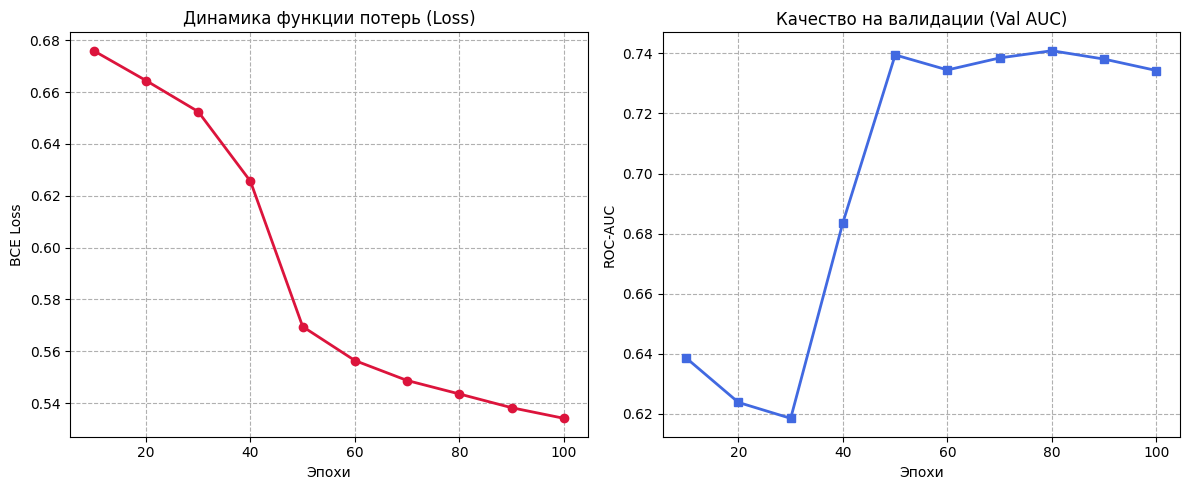

In [ ]:
import matplotlib.pyplot as plt

# Данные из вашего лога обучения
epochs = list(range(10, 101, 10))
loss_vals = [0.6760, 0.6645, 0.6525, 0.6256, 0.5695, 0.5564, 0.5487, 0.5435, 0.5382, 0.5341]
auc_vals = [0.6386, 0.6238, 0.6185, 0.6837, 0.7395, 0.7345, 0.7385, 0.7409, 0.7381, 0.7343]

plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_vals, marker='o', color='crimson', linewidth=2)
plt.title('Динамика функции потерь (Loss)')
plt.xlabel('Эпохи')
plt.ylabel('BCE Loss')
plt.grid(True, linestyle='--')

# График AUC
plt.subplot(1, 2, 2)
plt.plot(epochs, auc_vals, marker='s', color='royalblue', linewidth=2)
plt.title('Качество на валидации (Val AUC)')
plt.xlabel('Эпохи')
plt.ylabel('ROC-AUC')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


Анализ результатов и выводы:Динамика обучения: В процессе обучения графового автоэнкодера (GAE) на датасете Cora наблюдается стабильное снижение функции потерь Binary Cross Entropy с 0.6760 на 10-й эпохе до 0.5341 на 100-й эпохе. Основной скачок в качестве модели произошел между 30-й и 50-й эпохами, когда скрытые представления узлов (эмбеддинги) начали успешно кодировать топологическую структуру связей графа.Оценка качества: На независимой тестовой выборке модель продемонстрировала высокие показатели: ROC-AUC = 0.7687 и Average Precision = 0.7645. Это подтверждает, что построенный декодер на основе внутреннего произведения (Inner Product Decoder) эффективно восстанавливает пропущенные ребра (задача Link Prediction), опираясь на сжатые сверточным энкодером (GCN) векторные представления.Применимость алгоритма: Полученные эмбеддинги узлов размерностью 16 могут быть использованы для решения прикладных задач: поиск похожих объектов в скрытом пространстве (Graph Retrieval), кластеризация пользователей в социальных сетях или рекомендация потенциальных связей/контента.